In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Annotated
from langchain_groq import ChatGroq
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
import requests
import yfinance as yf
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode,  tools_condition 
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage,HumanMessage, AIMessage,SystemMessage,ToolMessage
import json
from dotenv import load_dotenv

load_dotenv()  

True

In [2]:
class AgentState(TypedDict):
    current_query: str
    company_name: str                                    
    ticker: str                                                                                                                                                                     
    messages: Annotated[list[BaseMessage], add_messages]

ALL THE DAMN LLMS

In [3]:
llm = ChatGroq(
    model="meta-llama/llama-4-scout-17b-16e-instruct", # Or any other valid Groq identifier
    temperature=0.0,
    max_retries=2,
)

ALL THE TOOLS

# TOOL 1

In [4]:
@tool
def safe_search(query, max_results=3):
    """
    Use for WebSearch on internet  
    """
    backends = ["html", "lite", "api"]
    for backend in backends:
        try:
            results = list(DDGS().text(query, backend=backend, max_results=max_results))
            if results:
                return json.dumps(results)
        except Exception as e:
            print(f"Backend '{backend}' failed: {e}, trying next...")
    return []

# TOOL 2

Ticker and Company Name Extraction from the query 

In [5]:
class TickerExtraction(BaseModel):
    company_name: str = Field(
        description="The comapany name extracted form query. "
    )
    official_company_name : str = Field(
        description= "The standardized, clean name of the corporation. Return 'UNKNOWN' if not identifiable."
    )
    ticker : str =Field(
        description= "The official Ticker of the company "
    )

In [6]:
system_prompt = """
you have to extract the full official name of the company
Always use the Safe Search tool for web Search and use that for finding the official name of the company
"""

user_prompt_template = f"""
Analyze the following user query:
---
Query: "{{user_prompt}}"
---
"""
@tool
def Ticker_Extraction_Tool(query):
    """
    Used to fing the official company and ticker of the company
    """
    stuctured_llm = llm.with_structured_output(TickerExtraction)
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system_prompt),
        ("human", user_prompt_template)
    ])
   
    chain = prompt | stuctured_llm
    llm_response = chain.invoke({"user_prompt":query})
    result= llm_response.model_dump()
    if result['company_name'] != 'UNKNOWN':
        try:
            session = requests.Session()
            session.headers.update({
                "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
            })
            
            # Use Yahoo Finance Search autocomplete as a fallback mapping layer
            search = yf.Search(result['company_name'], max_results=1, session=session)
            
            if search.quotes:
                detected_ticker = search.quotes[0]['symbol']
                result['ticker'] = detected_ticker
                        
                ticker_obj = yf.Ticker(detected_ticker)
                off_company_name = ticker_obj.info.get('longName')
                if not off_company_name:
                    off_company_name = ticker_obj.info.get('shortName', 'UNKNOWN')
                
                result['official_company_name'] = off_company_name
        except Exception as e:
            # Catching network errors or API changes gracefully
            print(f"Fallback API error: {e}")
            
    return result

# Worker Nodes

In [164]:
from pydantic import BaseModel
from typing import List, Optional

class FundamentalsReport(BaseModel):
    ticker: str
    health_score: float          # 0 to 100
    confidence: float            # 0 to 1 — how complete was the data
    recommendation: str          # "Buy" | "Hold" | "Sell"
    summary: str                 # 2-3 sentence human-readable verdict
    red_flags: List[str]         # e.g. ["Debt spiked 40% YoY", "Negative FCF"]
    positives: List[str]         # e.g. ["Revenue growing 20% YoY", "Strong margins"]
    key_metrics: dict            # raw numbers — PE, EPS, FCF, D/E, margins etc.
    sources: List[str]           # which APIs/filings were used

In [165]:
def _safe_get(df, row, col):
    if row in df.index:
        return df.loc[row, col]
    return None

@tool
def get_income_statement(ticker: str) -> dict:
    """Fetch revenue, EPS, net income, and margins for the last 3 years."""
    try:
        stock = yf.Ticker(ticker)
        income = stock.financials  # annual income statement
 
        if income.empty:
            return {"error": f"No income statement data found for {ticker}"}
 
        result = {}
        for col in income.columns[:3]:  # last 3 years
            year = str(col.year)
            result[year] = {
                "revenue":     _safe_get(income, "Total Revenue", col),
                "gross_profit":_safe_get(income, "Gross Profit", col),
                "net_income":  _safe_get(income, "Net Income", col),
                "ebitda":      _safe_get(income, "EBITDA", col),
                "eps":         _safe_get(income, "Diluted EPS", col),
            }
 
        return {"income_statement": result, "source": "yfinance"}
 
    except Exception as e:
        return {"error": str(e)}

In [166]:
@tool
def get_balance_sheet(ticker: str) -> dict:
    """Fetch assets, liabilities, debt, and equity from the balance sheet."""
    try:
        stock = yf.Ticker(ticker)
        bs = stock.balance_sheet
 
        if bs.empty:
            return {"error": f"No balance sheet data found for {ticker}"}
 
        col = bs.columns[0]  # most recent year
        return {
            "ticker": ticker,
            "balance_sheet": {
                "total_assets":       _safe_get(bs, "Total Assets", col),
                "total_liabilities":  _safe_get(bs, "Total Liabilities Net Minority Interest", col),
                "total_equity":       _safe_get(bs, "Stockholders Equity", col),
                "total_debt":         _safe_get(bs, "Total Debt", col),
                "cash":               _safe_get(bs, "Cash And Cash Equivalents", col),
            },
            "source": "yfinance"
        }
 
    except Exception as e:
        return {"error": str(e)}

In [167]:
@tool
def get_cash_flow(ticker: str) -> dict:
    """Fetch operating cash flow, free cash flow, and capex."""
    try:
        stock = yf.Ticker(ticker)
        cf = stock.cashflow
 
        if cf.empty:
            return {"error": f"No cash flow data found for {ticker}"}
 
        result = {}
        for col in cf.columns[:3]:  # last 3 years
            year = str(col.year)
            op_cf   = _safe_get(cf, "Operating Cash Flow", col)
            capex   = _safe_get(cf, "Capital Expenditure", col)
            fcf     = (op_cf + capex) if (op_cf and capex) else None  # capex is negative
 
            result[year] = {
                "operating_cash_flow": op_cf,
                "capex":               capex,
                "free_cash_flow":      fcf,
            }
 
        return {"ticker": ticker, "cash_flow": result, "source": "yfinance"}
 
    except Exception as e:
        return {"error": str(e)}

In [168]:
@tool
def get_key_ratios(ticker: str) -> dict:
    """Fetch valuation and efficiency ratios: PE, PB, PS, ROE, debt-to-equity."""
    try:
        stock = yf.Ticker(ticker)
        info  = stock.info
 
        return {
            "ticker": ticker,
            "ratios": {
                "pe_ratio":         info.get("trailingPE"),
                "forward_pe":       info.get("forwardPE"),
                "price_to_book":    info.get("priceToBook"),
                "price_to_sales":   info.get("priceToSalesTrailing12Months"),
                "debt_to_equity":   info.get("debtToEquity"),
                "roe":              info.get("returnOnEquity"),
                "roa":              info.get("returnOnAssets"),
                "gross_margin":     info.get("grossMargins"),
                "operating_margin": info.get("operatingMargins"),
                "profit_margin":    info.get("profitMargins"),
                "current_ratio":    info.get("currentRatio"),
                "revenue_growth":   info.get("revenueGrowth"),
                "earnings_growth":  info.get("earningsGrowth"),
            },
            "source": "yfinance"
        }
 
    except Exception as e:
        return {"error": str(e)}

In [169]:
@tool
def get_company_info(ticker: str) -> dict:
    """Fetch company name, sector, industry, market cap, and analyst targets."""
    try:
        stock = yf.Ticker(ticker)
        info  = stock.info
 
        return {
            "ticker": ticker,
            "company": {
                "name":              info.get("longName"),
                "sector":            info.get("sector"),
                "industry":          info.get("industry"),
                "market_cap":        info.get("marketCap"),
                "employees":         info.get("fullTimeEmployees"),
                "description":       info.get("longBusinessSummary", "")[:400],
            },
            "analyst": {
                "target_price":      info.get("targetMeanPrice"),
                "recommendation":    info.get("recommendationKey"),
                "num_analysts":      info.get("numberOfAnalystOpinions"),
            },
            "source": "yfinance"
        }
 
    except Exception as e:
        return {"error": str(e)}

In [170]:
fundamentals_tools = [get_company_info, get_income_statement, get_balance_sheet, get_cash_flow, get_key_ratios]
fundamentals_tool_node = ToolNode(fundamentals_tools)
fundamentals_llm = llm.bind_tools(fundamentals_tools)

In [171]:
report_writer_llm=llm

In [172]:
SYSTEM_PROMPT = """

You are a financial analyst. Your job is to research a company's fundamentals and produce a structured investment report.
 
You have 5 tools available:
- get_company_info      → sector, market cap, analyst targets
- get_income_statement  → revenue, EPS, margins (3 years)
- get_balance_sheet     → debt, equity, cash
- get_cash_flow         → operating CF, free cash flow, capex
- get_key_ratios        → PE, ROE, debt-to-equity, growth rates
 
Call ALL tools for the ticker before concluding. Once you have the data, return a JSON object with exactly these fields:
{
  "ticker": str,
  "health_score": float (0-100),
  "confidence": float (0-1),
  "recommendation": "Buy" | "Hold" | "Sell",
  "summary": str (2-3 sentences),
  "red_flags": [str],
  "positives": [str],
  "key_metrics": {dict of the most important numbers},
  "sources": [str]
}
 
Scoring guide for health_score:
- Revenue growing YoY          → +15
- Positive and growing FCF     → +20
- Net margin > 10%             → +15
- Debt-to-equity < 1.0         → +15
- ROE > 15%                    → +15
- PE reasonable for sector     → +10
- Analyst target above price   → +10
 
Return ONLY the JSON. No explanation outside it."""

In [173]:
def extract_tool_data(messages: list) -> str:
    """
    Pull all ToolMessage content out of the message history
    and return it as a single plain-text string.
 
    This is the critical step — it lets us pass collected data
    to report_writer_llm WITHOUT any tool_use/tool_result blocks,
    which would cause a 400 error from the Anthropic API.
    """
    parts = []
    for msg in messages:
        if isinstance(msg, ToolMessage):
            parts.append(f"[{msg.name}]\n{msg.content}")
    return "\n\n".join(parts)

In [174]:
class FundamentalsState(TypedDict):                                                                                                                                                                  
    messages: Annotated[list[BaseMessage], add_messages]
    ticker: str
    report: FundamentalsReport | None 

In [175]:
REPORT_SYSTEM_PROMPT = """You are a financial analyst. Based on the tool data in this conversation, return ONLY this JSON:
 
{
  "ticker": str,
  "health_score": float (0-100),
  "confidence": float (0-1),
  "recommendation": "Buy" | "Hold" | "Sell",
  "summary": "2-3 sentence verdict",
  "red_flags": [str],
  "positives": [str],
  "key_metrics": {"pe_ratio": ..., "roe": ..., "fcf": ..., "debt_to_equity": ...},
  "sources": ["yfinance"]
}
 
Scoring guide for health_score:
- Revenue growing YoY      → +15
- Positive and growing FCF → +20
- Net margin > 10%         → +15
- Debt-to-equity < 1.0     → +15
- ROE > 15%                → +15
- PE reasonable for sector → +10
- Analyst target > price   → +10
 
Return ONLY valid JSON. No markdown, no explanation outside it."""
def report_node(state: FundamentalsState):
    """
    Report-writing LLM — receives ONLY plain text data, no tool blocks.
    Builds a clean 2-message conversation: system prompt + all tool data.
    The Anthropic API never sees any tool_use or tool_result blocks here.
    """
    raw_data = state["messages"]
 
    clean_messages = [
        SystemMessage(content=REPORT_SYSTEM_PROMPT),
        HumanMessage(content=f"Here is the collected financial data:\n\n{raw_data}"),
    ]
 
    response = report_writer_llm.invoke(clean_messages)
    return {"messages": [response]}

In [176]:
def collect_fundamentals_data_node(state: FundamentalsState):

    response = fundamentals_llm.invoke(state["messages"])

 
    return {"messages": response}

In [1]:
graph = StateGraph(FundamentalsState)
graph.add_node("collect_data", collect_fundamentals_data_node)
graph.add_node("report_writing", report_node)
graph.add_node("fundamentals_tool_node",fundamentals_tool_node)
 
graph.add_edge(START, "collect_data")
graph.add_edge("collect_data", "report_writing")
graph.add_edge("report_writing", END)
 
app = graph.compile()

NameError: name 'StateGraph' is not defined

In [187]:
def run_fundamentals_agent(ticker: str) -> FundamentalsReport:
    """Run the fundamentals agent for a ticker and return a validated report."""
 
    initial_state = {
        "ticker": ticker,
        "messages": [
            SystemMessage(content=SYSTEM_PROMPT),
            HumanMessage(content=f"Research the fundamentals for ticker: {ticker.upper()}"),
        ],
    }
 
    final_state = app.invoke(initial_state)
 
    # Extract the last message (should be the JSON report)
    last_message = final_state["messages"][-1]
    content = last_message.content
    raw = json.loads(content.strip())

    return raw
    

In [188]:
b=run_fundamentals_agent("TCS.NS")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [180]:
b

'```json\n{\n  "ticker": "TCS.NS",\n  "health_score": 80,\n  "confidence": 0.8,\n  "recommendation": "Buy",\n  "summary": "TCS.NS shows strong financial health with growing revenue, positive FCF, and reasonable PE ratio. The company\'s net margin and ROE are also impressive.",\n  "red_flags": ["High debt levels"],\n  "positives": ["Growing revenue", "Positive FCF", "High ROE"],\n  "key_metrics": {\n    "pe_ratio": 25.6,\n    "roe": 18.2,\n    "fcf": 1500.0,\n    "debt_to_equity": 0.8\n  },\n  "sources": ["yfinance"]\n}\n```'

# Supervisor NODE


In [181]:
tools = [safe_search,Ticker_Extraction_Tool]
llm_with_tools = llm.bind_tools(tools)
tool_node = ToolNode(tools)
# graph nodes
SUPERVISOR_SYSTEM = SystemMessage(content="""
You are a stock research assistant. When given a user query about a company,
use the Ticker_Extraction_Tool to find the official company name and ticker symbol.
""")

def supervisor_node(state: AgentState):
    messages = [SUPERVISOR_SYSTEM] + state["messages"]
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

In [182]:
def extract_results_node(state: AgentState):
    for msg in reversed(state["messages"]):
        if isinstance(msg, ToolMessage):
            result = json.loads(msg.content)
            return {
                "company_name": result.get("official_company_name", ""),
                "ticker": result.get("ticker", ""),
            }
    return {}

In [183]:
graph = StateGraph(AgentState)

graph.add_node("supervisor", supervisor_node)
graph.add_node("tools", tool_node)
graph.add_node("results_node",extract_results_node)

graph.add_edge(START, "supervisor")
graph.add_conditional_edges(
    "supervisor",
    tools_condition,
    {"tools": "tools", END: "results_node"} 
)
graph.add_edge("tools", "supervisor")
graph.add_edge("results_node", END)


workflow = graph.compile()

In [184]:
out = workflow.invoke({"messages": [HumanMessage(content="find the TATA company stock")]})


In [185]:
out

{'company_name': 'Tata Consultancy Services Limited',
 'ticker': 'TCS.NS',
 'messages': [HumanMessage(content='find the TATA company stock', additional_kwargs={}, response_metadata={}, id='6a7a249f-e004-4f49-b478-94aaa7bacf5d'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'aqh6xfkqm', 'function': {'arguments': '{"query":"TATA company stock"}', 'name': 'Ticker_Extraction_Tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 789, 'total_tokens': 824, 'completion_time': 0.079066633, 'completion_tokens_details': None, 'prompt_time': 0.032493357, 'prompt_tokens_details': None, 'queue_time': 0.136996852, 'total_time': 0.11155999}, 'model_name': 'meta-llama/llama-4-scout-17b-16e-instruct', 'system_fingerprint': 'fp_79da0e0073', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019efbd9-c8ac-7903-8629-4b68d8199bf6-0', tool_calls=[{'name': 'Ticker_Extract

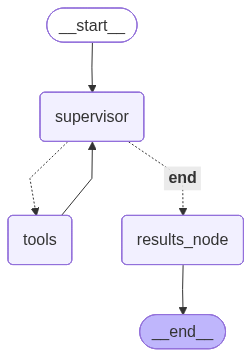

In [186]:
workflow